In [14]:
## Load my files ##
import sys
sys.path.append('..')
from utils import get_sequence

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

# Proposed model

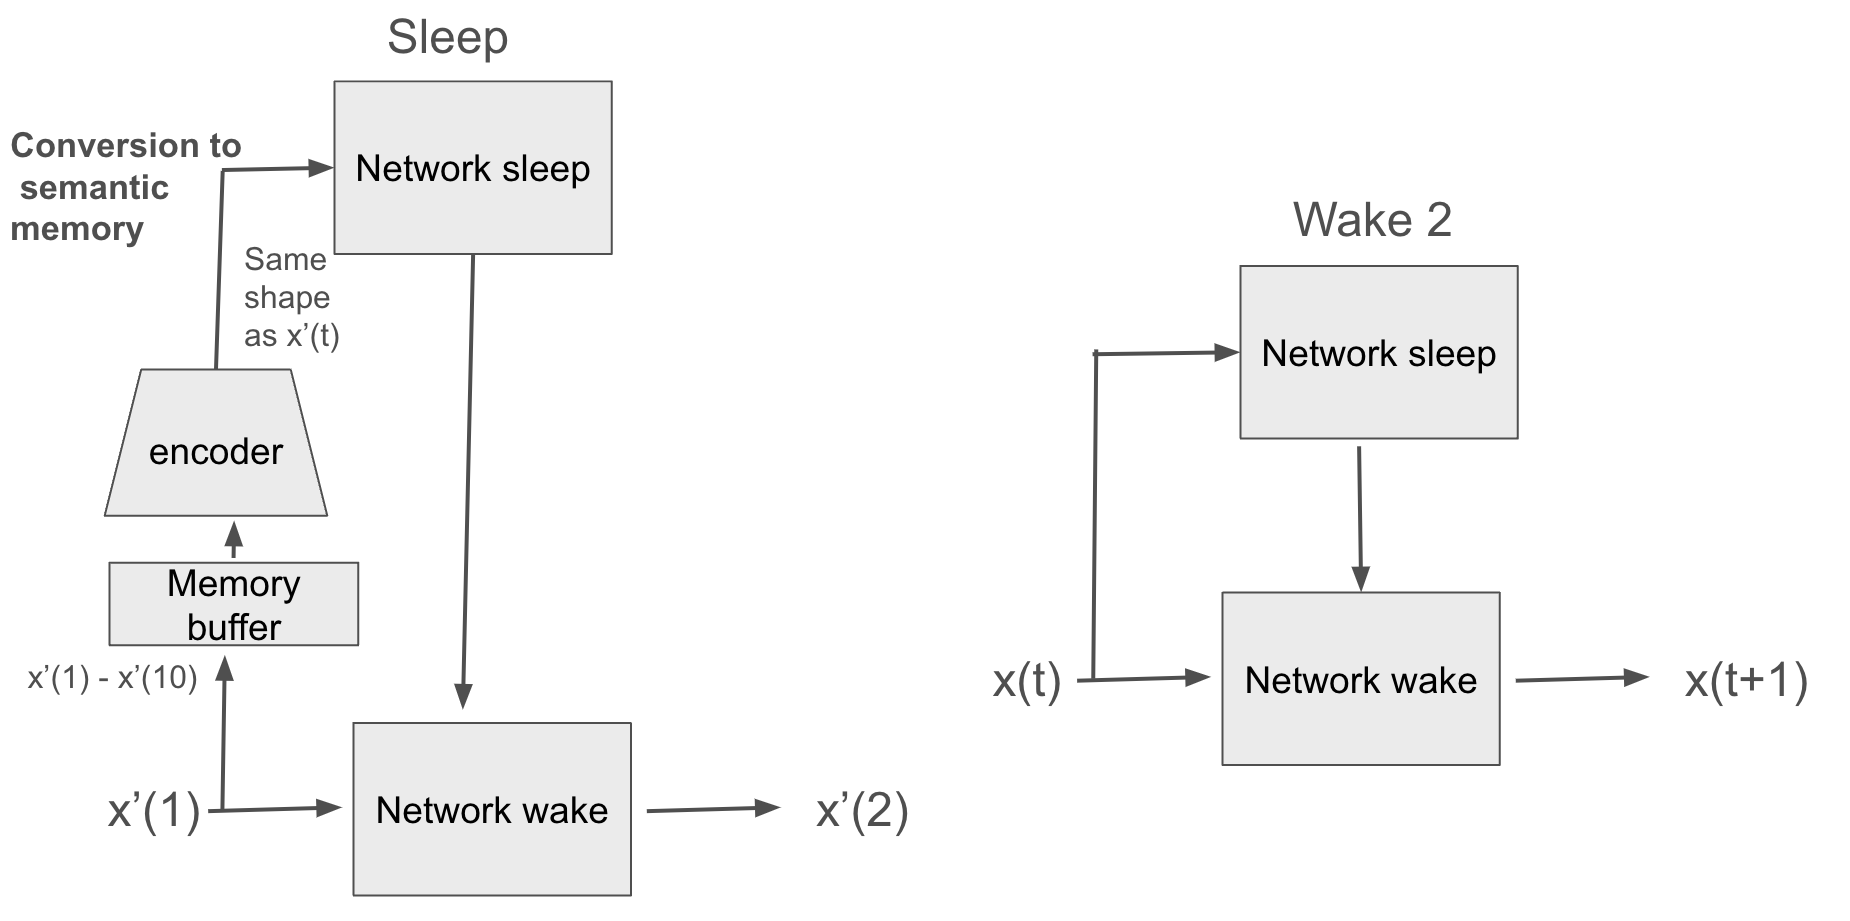

## Experiment 2:
### Observation: During sleep Hippocampus feeds compressed data to Neo-cortex.

### Hypothesis: Distributing learning to Neo-cortex in compressed form improves performance.






In [9]:
n_community = 2
n_members = 3

tokens = []

for ii in range(n_community*n_members+1):
    tokens.append(
        chr(ord('A')+ii)
    )

In [10]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size_hippocampus, hidden_size_cortex, memory_buffer, num_layers_hippocampus=1, num_layers_cortex=1):
        super(RNN, self).__init__()
        self.cortex_hidden = torch.zeros(1, 1, hidden_size_cortex)
        
        self.hidden_size_cortex = hidden_size_cortex
        self.hidden_size_hippocampus = hidden_size_hippocampus
        self.memory_buffer = memory_buffer
        self.rnn_hippocampus = nn.RNN(input_size+hidden_size_cortex, hidden_size_hippocampus, num_layers_hippocampus, batch_first=True)
        self.rnn_cortex = nn.RNN(input_size, hidden_size_cortex, num_layers_cortex, batch_first=True)
        
        self.fc = nn.Linear(hidden_size_hippocampus, len(tokens))

        self.buffer_encoder_layer1 = nn.Linear(memory_buffer, 3*len(tokens))
        self.buffer_encoder_layer2 = nn.Linear(3*len(tokens), len(tokens))
        
    def forward(self, x, h0=None, hc=None, sleep=False, compress=False, memory_replay=None):
        if sleep:
            if compress:
                out = self.buffer_encoder_layer1(memory_replay)
                out = nn.functional.relu(out)
                out = self.buffer_encoder_layer2(out)
                # out = nn.functional.relu(out)
                out = nn.functional.softmax(out, dim=2)
            else:
                out = x.clone()

            # print(out)
            #########################################################
            if hc == None:
                cortex_out, hc = self.rnn_cortex(out)
            else:
                cortex_out, hc = self.rnn_cortex(out, hc)

            # print(cortex_out)
            x = torch.cat((x,cortex_out), dim=2)
                
            if h0 == None:
                out, h0 = self.rnn_hippocampus(x)
            else:   
                out, h0 = self.rnn_hippocampus(x, h0)
    
            out = self.fc(out)
        else:
            x = torch.cat((x,self.cortex_hidden), dim=2)
                
            if h0 == None:
                out, h0 = self.rnn_hippocampus(x)
            else:   
                out, h0 = self.rnn_hippocampus(x, h0)
    
            out = self.fc(out)
        
        
 
        # else:
        #     x = torch.cat((x,self.cortex_hidden), dim=2)
        #     if h0 == None:
        #         out, h0 = self.rnn_hippocampus(x)
        #     else:   
        #         out, h0 = self.rnn_hippocampus(x, h0)
            
        if sleep:
            return out[:,-1,:], h0, hc

        return out[:,-1,:], h0

In [11]:
class Dataset_converter(Dataset):
    def __init__(self, data, working_memory=1, short_term_memory=8):
        
        one_hot_encoded = np.zeros((len(data), len(tokens)), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory, len(tokens)*working_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), len(tokens)))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                for kk in range(working_memory):
                    self.X[ii,jj,kk*len(tokens):(kk+1)*len(tokens)] = \
                    one_hot_encoded[ii+jj+kk,:]
                    
            self.y[ii] = \
                one_hot_encoded[ii+jj+kk+1,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [12]:
def generate_sleep_samples(main_model, n_samples):
    seq = ''
    idx = torch.randint(0, len(tokens), (1,)) [0]
    X_hat = torch.zeros(len(tokens),dtype=torch.float32)
    X_hat[idx] = 1.0
    
    for ii in range(n_samples+50):
        if ii == 0:
            # seq += tokens[idx]        
            X_hat, mem = main_model(X_hat.reshape(1,1,-1))
        else:
            X_hat, mem = main_model(X_hat, mem)
    
        # mem = mem + 1e-1*torch.rand(mem.shape)
        # X_hat = torch.tensor(X_hat, requires_grad=False)
        X_hat = torch.nn.functional.softmax(X_hat, dim=1)
        dist_categ = torch.distributions.Categorical(probs=X_hat.reshape(-1))
        idx = dist_categ.sample()
    
        X_hat = torch.zeros(len(tokens),dtype=torch.float32)
        X_hat[idx] = 1.0
        X_hat = X_hat.reshape(1,1,-1)   
    
        if ii>50:
            seq += tokens[idx]

    return seq

In [23]:
### initial training ###
total_samples = 100000
initial_training_sample = 20000
sleep_samples = 20000
working_memory = 1
short_term_memory = 1
hidden_size_hippocampus = 3
hidden_size_cortex = 100
memory_buffer = 10*len(tokens)
num_layers = 1
lr = 9e-4
lr_sleep = 9e-4
lambda_reg = 1e-8
reps = 5
test_acc = [[] for _ in range(reps)]

for rep in range(reps):
    print('Doing rep ', rep)
    
    data = get_sequence(total_samples, 2, 3, random_state=rep)
    data_test = get_sequence(total_samples+sleep_samples, 2, 3, random_state=rep)
    data_set = Dataset_converter(data[:initial_training_sample], working_memory, short_term_memory)
    data_set_test = Dataset_converter(data_test[:initial_training_sample], working_memory, short_term_memory)
    
    main_model = RNN(len(tokens)*working_memory, hidden_size_hippocampus, hidden_size_cortex, memory_buffer, num_layers)
    main_model.rnn_cortex.requires_grad = False
    main_model.buffer_encoder_layer1.requires_grad = False
    main_model.buffer_encoder_layer2.requires_grad = False
    
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    
    optimizer = torch.optim.SGD(main_model.parameters(), lr=lr, momentum=0.95)
    criterion = torch.nn.CrossEntropyLoss()
    
    total = 0
    correct = np.zeros(1000,dtype=float)
    for (X, y), (X_test, y_test) in zip(train_loader, test_loader):
        optimizer.zero_grad()
    
        if total == 0:
            predicted_y, hidden = main_model(X)
        else:
            predicted_y, hidden = main_model(X, mem)
            
        loss = criterion(predicted_y, y)
        loss.backward(retain_graph=True)
        optimizer.step()
    
        with torch.no_grad():
            mem = hidden.clone()
            
            if total == 0:
                predicted_y, hidden_ = main_model(X_test)
            else:
                predicted_y, hidden_ = main_model(X_test, hidden_)

            
            true_y = y_test.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)
    
            total += 1
            if true_y == estimated_y:
                    correct[total%1000] = 1
            else:
                correct[total%1000] = 0
    
            test_acc[rep].append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            if total%1000 == 0:
                print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[rep][-1]:.4f}')


    print('Going to sleep ...')
    data_sleep = generate_sleep_samples(main_model, sleep_samples)
    main_model.rnn_cortex.requires_grad = True
    main_model.buffer_encoder_layer1.requires_grad = True
    main_model.buffer_encoder_layer2.requires_grad = True
    
    data_set = Dataset_converter(data_sleep, memory_buffer//len(tokens), short_term_memory)
    sleep_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    optimizer = torch.optim.SGD(main_model.parameters(), lr=lr_sleep)
    # optimizer = torch.optim.SGD(main_model.parameters(), lr=lr, momentum=0.95)
    
    criterion = torch.nn.CrossEntropyLoss()
    sleep_iter = 0
    
    for X, y in sleep_loader:
        optimizer.zero_grad()
        y = X[0][:,-len(tokens):].clone()
        
        if sleep_iter == 0:
            predicted_y, hidden, hidden_sleep = main_model(X[0][:,-2*len(tokens):-len(tokens)].reshape(1,1,-1), sleep=True, compress=True, memory_replay=X)
        else:
            predicted_y, hidden, hidden_sleep = main_model(X[0][:,-2*len(tokens):-len(tokens)].reshape(1,1,-1), mem, mem_, sleep=True, compress=True, memory_replay=X)
            
        loss = criterion(predicted_y, y)
        l1_norm = sum(p.abs().sum() for p in main_model.rnn_hippocampus.parameters())
        loss += lambda_reg * l1_norm
        
        loss.backward()
        optimizer.step()
    
        with torch.no_grad():
            mem = hidden.clone()
            mem_ = hidden_sleep.clone()
            
            true_y = y.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)
    
            sleep_iter += 1
            if true_y == estimated_y:
                correct[sleep_iter%1000] = 1
            else:
                correct[sleep_iter%1000] = 0
    
            test_acc[rep].append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            if sleep_iter%1000 == 0:
                print(f'Iter : {sleep_iter+1}, loss: {loss:.4f}, accuracy: {test_acc[rep][-1]:.4f}')


    print('Going to awake phase ...')
    # data_sleep = generate_sleep_samples(main_model, sleep_samples)
    main_model.rnn_cortex.requires_grad = False
    main_model.buffer_encoder_layer1.requires_grad = False
    main_model.buffer_encoder_layer2.requires_grad = False
    data_set = Dataset_converter(data[initial_training_sample:], working_memory, short_term_memory)
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 

    data_set = Dataset_converter(data_test[initial_training_sample:], working_memory, short_term_memory)
    test_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    optimizer = torch.optim.SGD(main_model.parameters(), lr=5e-4, momentum=0.95)
    criterion = torch.nn.CrossEntropyLoss()
    sleep_iter = 0
    
    for (X, y), (X_test, y_test) in zip(train_loader, test_loader):
        optimizer.zero_grad()
    
        if sleep_iter == 0:
            predicted_y, hidden, hidden_sleep = main_model(X, sleep=True)
        else:
            predicted_y, hidden, hidden_sleep = main_model(X, mem, mem_, sleep=True)
            
        loss = criterion(predicted_y, y)
        loss.backward()
        optimizer.step()
    
        with torch.no_grad():
            mem = hidden.clone()
            mem_ = hidden_sleep.clone()
            
            if sleep_iter == 0:
                predicted_y, hidden_, hidden_sleep_ = main_model(X_test, sleep=True)
            else:
                predicted_y, hidden_, hidden_sleep_ = main_model(X_test, hidden_, hidden_sleep_, sleep=True)
                
            true_y = y_test.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)
    
            sleep_iter += 1
            if true_y == estimated_y:
                    correct[sleep_iter%1000] = 1
            else:
                correct[sleep_iter%1000] = 0
    
            test_acc[rep].append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            if sleep_iter%1000 == 0:
                print(f'Iter : {sleep_iter+1}, loss: {loss:.4f}, accuracy: {test_acc[rep][-1]:.4f}')

Doing rep  0
Iter : 1001, loss: 2.0754, accuracy: 0.2960
Iter : 2001, loss: 2.0833, accuracy: 0.3780
Iter : 3001, loss: 1.3012, accuracy: 0.4830
Iter : 4001, loss: 1.4008, accuracy: 0.5330
Iter : 5001, loss: 2.7552, accuracy: 0.5460
Iter : 6001, loss: 2.7631, accuracy: 0.5690
Iter : 7001, loss: 0.5481, accuracy: 0.5720
Iter : 8001, loss: 1.9052, accuracy: 0.5350
Iter : 9001, loss: 1.4610, accuracy: 0.5600
Iter : 10001, loss: 2.1956, accuracy: 0.5940
Iter : 11001, loss: 1.7361, accuracy: 0.5780
Iter : 12001, loss: 2.1827, accuracy: 0.5860
Iter : 13001, loss: 1.4432, accuracy: 0.5780
Iter : 14001, loss: 1.7691, accuracy: 0.5700
Iter : 15001, loss: 0.7208, accuracy: 0.5670
Iter : 16001, loss: 1.9796, accuracy: 0.5630
Iter : 17001, loss: 1.6057, accuracy: 0.6060
Iter : 18001, loss: 1.8285, accuracy: 0.5870
Iter : 19001, loss: 1.5222, accuracy: 0.5930
Going to sleep ...
Iter : 1001, loss: 0.4156, accuracy: 0.5980
Iter : 2001, loss: 0.0685, accuracy: 0.6090
Iter : 3001, loss: 0.1355, accurac

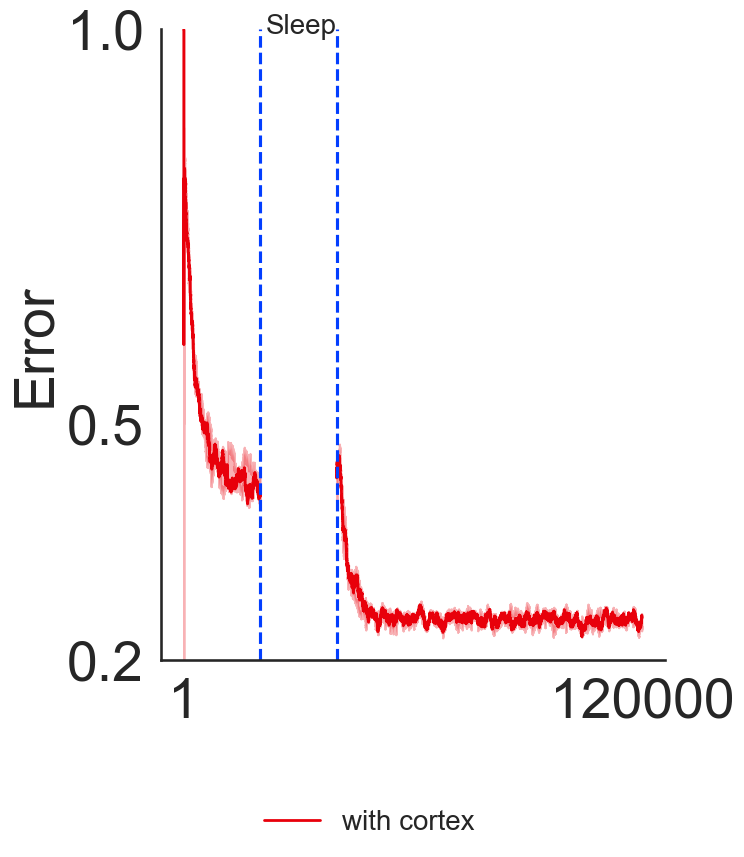

In [27]:
test_acc = np.array(test_acc)
# test_acc_not_sparse = np.array(test_acc_not_sparse)
# test_acc_control = np.array(test_acc_control)
sleep_break = 20000
sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
font = 40

fig, ax = plt.subplots(1, 1, figsize=(8,8), sharex=True, sharey=True)

# ax.hlines(0.1, 0, total_samples+sleep_break, linestyles='dashed', label='Optimal Performance', color='k')

ax.plot(np.median(1-test_acc[:,:initial_training_sample],axis=0),linewidth=2, color='r', label='with cortex')
ax.fill_between(np.arange(1,initial_training_sample+1), np.quantile(1-test_acc[:,:initial_training_sample], 0.25, axis=0), np.quantile(1-test_acc[:,:initial_training_sample], 0.75, axis=0), color='r', alpha=.3)

ax.plot(np.arange(initial_training_sample+sleep_break,initial_training_sample+sleep_break+len(test_acc[0][initial_training_sample+sleep_samples:])), np.median(1-test_acc[:,initial_training_sample+sleep_samples:],axis=0),linewidth=2, color='r')
ax.fill_between(np.arange(initial_training_sample+sleep_break,initial_training_sample+sleep_break+len(test_acc[0][initial_training_sample+sleep_samples:])), np.quantile(1-test_acc[:,initial_training_sample+sleep_samples:], 0.25, axis=0), np.quantile(1-test_acc[:,initial_training_sample+sleep_samples:], 0.75, axis=0), color='r', alpha=.3)


# ax.plot(np.median(1-test_acc_not_sparse[:,:initial_training_sample],axis=0),linewidth=2, color='b', label='with cortex no sparsity')
# ax.fill_between(np.arange(1,initial_training_sample+1), np.quantile(1-test_acc_not_sparse[:,:initial_training_sample], 0.25, axis=0), np.quantile(1-test_acc_not_sparse[:,:initial_training_sample], 0.75, axis=0), color='b', alpha=.3)

# ax.plot(np.arange(initial_training_sample+sleep_break,initial_training_sample+sleep_break+len(test_acc_not_sparse[0][initial_training_sample+sleep_samples:])), np.median(1-test_acc_not_sparse[:,initial_training_sample+sleep_samples:],axis=0),linewidth=2, color='b')
# ax.fill_between(np.arange(initial_training_sample+sleep_break,initial_training_sample+sleep_break+len(test_acc_not_sparse[0][initial_training_sample+sleep_samples:])), np.quantile(1-test_acc_not_sparse[:,initial_training_sample+sleep_samples:], 0.25, axis=0), np.quantile(1-test_acc_not_sparse[:,initial_training_sample+sleep_samples:], 0.75, axis=0), color='b', alpha=.3)

ax.vlines(initial_training_sample, 0.2, 1, linestyles='dashed', color='b')
ax.vlines(initial_training_sample+sleep_break, 0.2, 1, linestyles='dashed', color='b')


# ax.plot(np.median(1-test_acc_control[:,:initial_training_sample],axis=0),linewidth=2, color='k', label='without cortex')
# ax.fill_between(np.arange(1,initial_training_sample+1), np.quantile(1-test_acc_control[:,:initial_training_sample], 0.25, axis=0), np.quantile(1-test_acc_control[:,:initial_training_sample], 0.75, axis=0), color='k', alpha=.3)

# ax.plot(np.arange(initial_training_sample+sleep_break,initial_training_sample+sleep_break+len(test_acc_control[0][initial_training_sample:])), np.median(1-test_acc_control[:,initial_training_sample:],axis=0),linewidth=2, color='k')
# ax.fill_between(np.arange(initial_training_sample+sleep_break,initial_training_sample+sleep_break+len(test_acc_control[0][initial_training_sample:])), np.quantile(1-test_acc_control[:,initial_training_sample:], 0.25, axis=0), np.quantile(1-test_acc_control[:,initial_training_sample:], 0.75, axis=0), color='k', alpha=.3)

ax.set_ylim([.2,1])
plt.xticks([1, total_samples+sleep_break])
plt.yticks([0.2, 0.5, 1.0])

ax.set_ylabel('Error', fontsize=font)
# ax.set_yscale('log') 


ax.tick_params(labelsize=40)
    
right_side = ax.spines["right"]
right_side.set_visible(False)
top_side = ax.spines["top"]
top_side.set_visible(False)

fig.text(.37, .92, 'Sleep', rotation=0, fontsize=20)
fig.legend(bbox_to_anchor=(0.5, -0.02), bbox_transform=plt.gcf().transFigure,
                        ncol=2, loc='upper center', fontsize=20, frameon=False)
plt.tight_layout()
